Random Seed: 999
Device: cuda:0
GPU: NVIDIA GeForce RTX 5070 Laptop GPU  torch.cuda: 13.0
OUT_DIR: ./wgan_gp_mri_outputs\run_20260326_162359
Train classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Test  classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Using ALL classes (unconditional). Train: 5600 Test: 1600


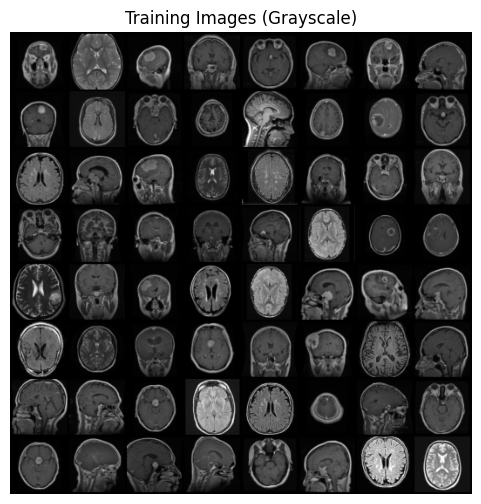

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)


c:\Users\22958\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


[TEST] epoch 1/40  mean D(real)=-2.980  mean D(fake)=-10.383
[FID ] epoch 1/40  FID=304.8247
[KID ] epoch 1/40  KID_mean=0.374562  KID_std=0.011580
[BEST] New best FID = 304.8247 at epoch 1
[2/40] iter   100  LossD=-7.8277 LossG=10.2321  D(real)=-0.203 D(fake)=-10.547 GP=0.252
[TEST] epoch 2/40  mean D(real)=-10.515  mean D(fake)=-16.969
[FID ] epoch 2/40  FID=263.0895
[KID ] epoch 2/40  KID_mean=0.300714  KID_std=0.014518
[BEST] New best FID = 263.0895 at epoch 2
[3/40] iter   200  LossD=-7.1696 LossG=16.8450  D(real)=-8.770 D(fake)=-16.805 GP=0.086
[TEST] epoch 3/40  mean D(real)=-10.084  mean D(fake)=-14.193
[FID ] epoch 3/40  FID=199.2816
[KID ] epoch 3/40  KID_mean=0.215775  KID_std=0.009600
[BEST] New best FID = 199.2816 at epoch 3
[4/40] iter   300  LossD=-4.3892 LossG=17.5922  D(real)=-14.319 D(fake)=-19.556 GP=0.085
[TEST] epoch 4/40  mean D(real)=-11.052  mean D(fake)=-15.121
[FID ] epoch 4/40  FID=172.7639
[KID ] epoch 4/40  KID_mean=0.173003  KID_std=0.010232
[BEST] New bes

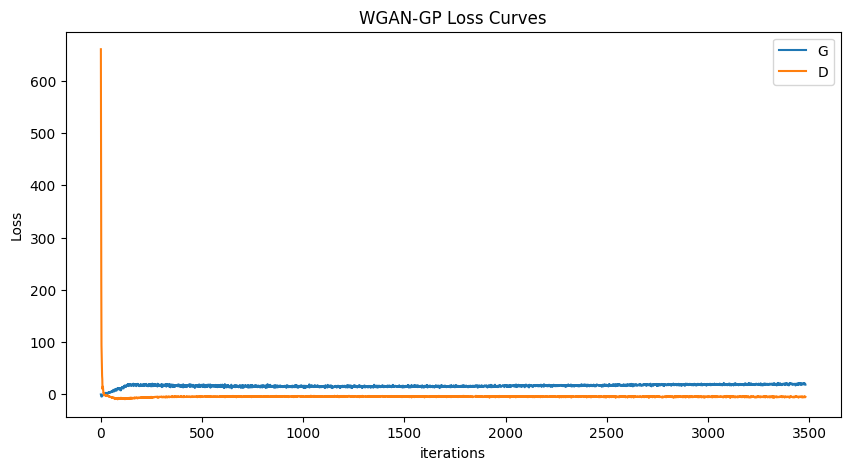

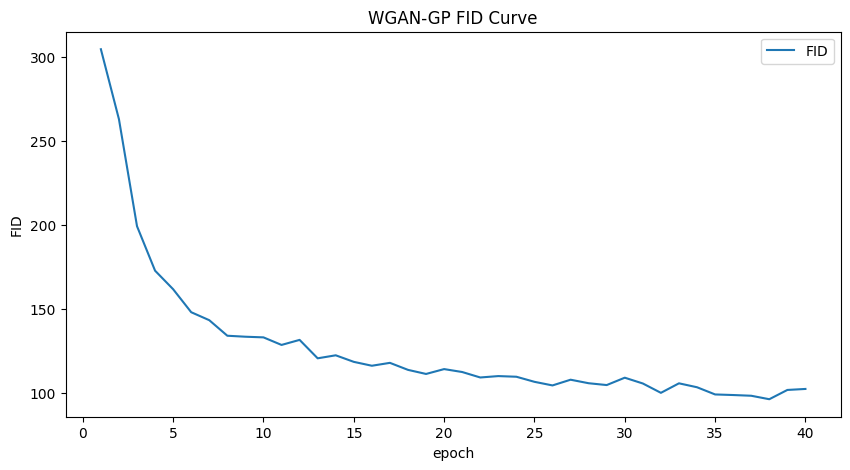

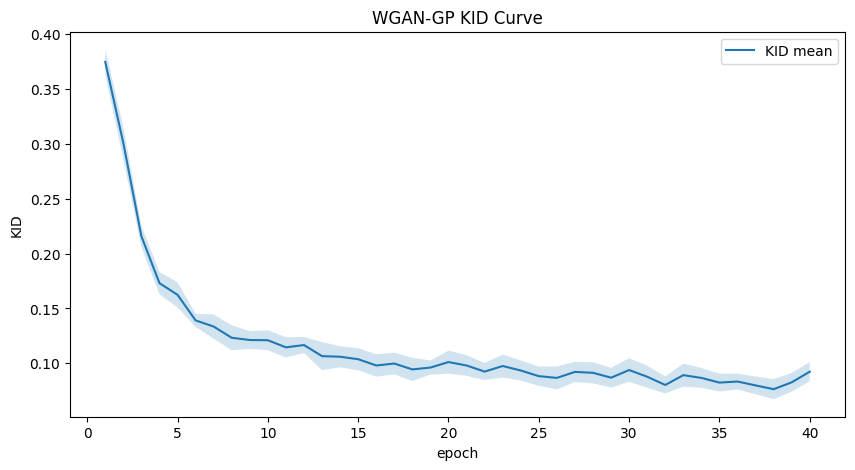

Done. Outputs saved to: ./wgan_gp_mri_outputs\run_20260326_162359
Best FID: 96.1223 at epoch 38
Loaded best-FID generator: ./wgan_gp_mri_outputs\run_20260326_162359\netG_best_fid.pth


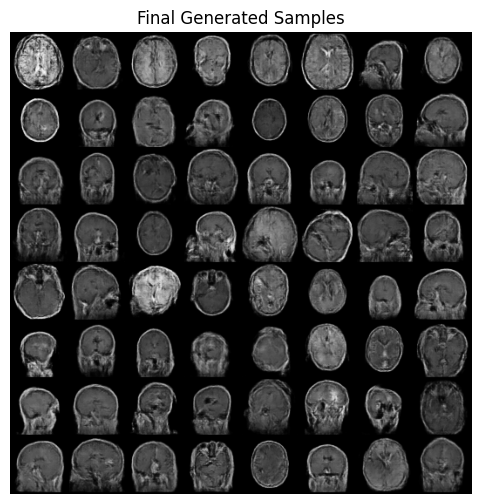

In [8]:
# ============================================================
# WGAN-GP for Grayscale MRI 64x64 (ImageFolder)  [UNCONDITIONAL]
# + FID + KID evaluation
# - Uses ALL images (ignore class labels) OR Step0 single-class subset
# - Critic (no sigmoid), Wasserstein loss + Gradient Penalty
# - Saves: fixed samples + random samples + checkpoints + metrics.csv
# ============================================================

import os
import time
import random
import csv
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt

# ===== FID / KID =====
try:
    from torchmetrics.image.fid import FrechetInceptionDistance
    from torchmetrics.image.kid import KernelInceptionDistance
except ImportError as e:
    raise ImportError(
        "Missing packages. Please run:\n"
        "py -m pip install \"torchmetrics[image]\" torch-fidelity\n"
        "or:\n"
        "python -m pip install \"torchmetrics[image]\" torch-fidelity"
    ) from e

# -------------------------
# 0) Seed / device
# -------------------------
manualSeed = 999
print("Random Seed:", manualSeed)
random.seed(manualSeed)
np.random.seed(manualSeed)
torch.manual_seed(manualSeed)

torch.use_deterministic_algorithms(False)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0), " torch.cuda:", torch.version.cuda)

# -------------------------
# 1) Paths / output
# -------------------------
TRAIN_ROOT = r"C:\Users\22958\Desktop\毕业论文\archive\Training"
TEST_ROOT  = r"C:\Users\22958\Desktop\毕业论文\archive\Testing"

RUN_ID = time.strftime("run_%Y%m%d_%H%M%S")
OUT_DIR = os.path.join("./wgan_gp_mri_outputs", RUN_ID)
os.makedirs(OUT_DIR, exist_ok=True)
print("OUT_DIR:", OUT_DIR)

# -------------------------
# 2) Hyperparameters
# -------------------------
workers = 0
batch_size = 64
image_size = 64
nc = 1
nz = 100
ngf = 64
ndf = 64

num_epochs = 40
lrD = 1e-4
lrG = 2e-4
betas = (0.0, 0.9)

lambda_gp = 10.0
n_critic = 3

SAVE_EVERY_ITERS = 200
LOG_EVERY_ITERS  = 100

# Step0 (optional): set None to use ALL classes; or "notumor"/"glioma"/...
TARGET_CLASS = None

# Eval config:
MAX_EVAL_IMAGES = None    # 调试时可设 100 / 500
KID_SUBSET_SIZE = 50      # 调试时可设 20
KID_SUBSETS = 20          # 调试时可设 5

# -------------------------
# 3) Dataset / Loader
# -------------------------
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_full = dset.ImageFolder(root=TRAIN_ROOT, transform=transform)
test_full  = dset.ImageFolder(root=TEST_ROOT,  transform=transform)

print("Train classes:", train_full.classes)
print("Test  classes:", test_full.classes)
assert train_full.classes == test_full.classes, "Train/Test class order mismatch!"

def filter_one_class(ds: dset.ImageFolder, class_name: str):
    idx = ds.class_to_idx[class_name]
    keep = [i for i, (_, y) in enumerate(ds.samples) if y == idx]
    return Subset(ds, keep)

if TARGET_CLASS is None:
    train_ds = train_full
    test_ds  = test_full
    print("Using ALL classes (unconditional). Train:", len(train_ds), "Test:", len(test_ds))
else:
    train_ds = filter_one_class(train_full, TARGET_CLASS)
    test_ds  = filter_one_class(test_full,  TARGET_CLASS)
    print(f"Filtered to '{TARGET_CLASS}' only. Train:", len(train_ds), "Test:", len(test_ds))

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=workers,
    pin_memory=(device.type == "cuda"),
    drop_last=True
)
test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=workers,
    pin_memory=(device.type == "cuda"),
    drop_last=False
)

# -------------------------
# 4) Visualize a batch
# -------------------------
real_batch = next(iter(train_loader))[0]
plt.figure(figsize=(6, 6))
plt.axis("off")
plt.title("Training Images (Grayscale)")
grid = vutils.make_grid(real_batch[:64], padding=2, normalize=True)
plt.imshow(grid[0], cmap="gray")
plt.show()

# -------------------------
# 5) Weight init
# -------------------------
def weights_init(m):
    cname = m.__class__.__name__
    if ("Conv" in cname) or ("Linear" in cname):
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 0.0, 0.02)
    if "BatchNorm" in cname:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

# -------------------------
# 6) Models (WGAN-GP)
# -------------------------
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8), nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4), nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2), nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.main(z)

class Critic(nn.Module):
    """No sigmoid. Output is real-valued score."""
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf * 2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf * 8, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False)  # -> [B,1,1,1]
        )

    def forward(self, x):
        return self.main(x).view(-1)

netG = Generator().to(device)
netD = Critic().to(device)
netG.apply(weights_init)
netD.apply(weights_init)

print(netG)
print(netD)

optG = optim.Adam(netG.parameters(), lr=lrG, betas=betas)
optD = optim.Adam(netD.parameters(), lr=lrD, betas=betas)

# -------------------------
# 7) Gradient penalty
# -------------------------
def gradient_penalty(netD, real, fake):
    b = real.size(0)
    eps = torch.rand(b, 1, 1, 1, device=device)
    x_hat = eps * real + (1.0 - eps) * fake
    x_hat.requires_grad_(True)

    d_hat = netD(x_hat)
    grad = torch.autograd.grad(
        outputs=d_hat.sum(),
        inputs=x_hat,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    grad = grad.view(b, -1)
    gp = ((grad.norm(2, dim=1) - 1.0) ** 2).mean()
    return gp

# -------------------------
# 8) Sampling helpers
# -------------------------
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

@torch.no_grad()
def save_samples(tag: str):
    netG.eval()
    fake_fixed = netG(fixed_noise).detach().cpu()

    z = torch.randn(64, nz, 1, 1, device=device)
    fake_rand = netG(z).detach().cpu()

    vutils.save_image(
        fake_fixed,
        os.path.join(OUT_DIR, f"{tag}_fixed.png"),
        normalize=True,
        nrow=8
    )
    vutils.save_image(
        fake_rand,
        os.path.join(OUT_DIR, f"{tag}_rand.png"),
        normalize=True,
        nrow=8
    )
    netG.train()

@torch.no_grad()
def sanity_scores(loader, n_batches=10):
    """Sanity only: mean D(real) vs mean D(fake) on a few batches."""
    netG.eval()
    netD.eval()
    rs, fs = [], []

    for k, (real, _) in enumerate(loader):
        if k >= n_batches:
            break
        real = real.to(device)
        b = real.size(0)
        z = torch.randn(b, nz, 1, 1, device=device)
        fake = netG(z)
        rs.append(netD(real).mean().item())
        fs.append(netD(fake).mean().item())

    netG.train()
    netD.train()
    return float(np.mean(rs)), float(np.mean(fs))

# -------------------------
# 8.5) FID / KID helpers
# -------------------------
def to_metric_input(x):
    """
    x: tensor in [-1,1], shape [B,1,H,W] or [B,3,H,W]
    return: float32 tensor in [0,1], 3-channel
    """
    x = x.detach().clamp(-1, 1)
    x = (x + 1.0) / 2.0   # [-1,1] -> [0,1]

    if x.size(1) == 1:
        x = x.repeat(1, 3, 1, 1)  # grayscale -> pseudo RGB

    return x.float()

def build_fid_metric(device):
    fid = FrechetInceptionDistance(
        feature=2048,
        reset_real_features=True,
        normalize=True
    ).to(device)
    return fid

def build_kid_metric(device, subset_size=50, subsets=20):
    subset_size = max(2, int(subset_size))
    kid = KernelInceptionDistance(
        feature=2048,
        subsets=subsets,
        subset_size=subset_size,
        reset_real_features=True,
        normalize=True
    ).to(device)
    return kid

@torch.no_grad()
def compute_fid_kid_wgan(
    netG,
    test_loader,
    device,
    nz,
    max_images=None,
    kid_subset_size=50,
    kid_subsets=20
):
    netG.eval()

    test_size = len(test_loader.dataset)
    effective_eval_n = test_size if max_images is None else min(test_size, max_images)
    effective_kid_subset_size = min(kid_subset_size, max(2, effective_eval_n))

    fid = build_fid_metric(device)
    kid = build_kid_metric(
        device,
        subset_size=effective_kid_subset_size,
        subsets=kid_subsets
    )

    seen = 0

    for real, _ in test_loader:
        real = real.to(device)
        b = real.size(0)

        if max_images is not None and seen + b > max_images:
            keep = max_images - seen
            if keep <= 0:
                break
            real = real[:keep]
            b = keep

        real_in = to_metric_input(real)
        fid.update(real_in, real=True)
        kid.update(real_in, real=True)

        z = torch.randn(b, nz, 1, 1, device=device)
        fake = netG(z)
        fake_in = to_metric_input(fake)

        fid.update(fake_in, real=False)
        kid.update(fake_in, real=False)

        seen += b

    fid_score = fid.compute().item()

    if effective_eval_n < 2:
        kid_mean, kid_std = float("nan"), float("nan")
    else:
        kid_mean_t, kid_std_t = kid.compute()
        kid_mean, kid_std = kid_mean_t.item(), kid_std_t.item()

    netG.train()
    return fid_score, kid_mean, kid_std

def save_metrics_csv(records, out_path):
    fieldnames = ["epoch", "test_D_real", "test_D_fake", "FID", "KID_mean", "KID_std"]
    with open(out_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(records)

# -------------------------
# 9) Train
# -------------------------
G_losses, D_losses = [], []
FID_scores = []
KID_means = []
KID_stds = []
epoch_records = []

best_fid = float("inf")
best_epoch = -1
iters = 0

print("Starting Training Loop...")
save_samples("init")

data_iter = iter(train_loader)

for epoch in range(num_epochs):
    for _ in range(len(train_loader)):
        # ----------- Train Critic n_critic times -----------
        for _c in range(n_critic):
            try:
                real, _ = next(data_iter)
            except StopIteration:
                data_iter = iter(train_loader)
                real, _ = next(data_iter)

            real = real.to(device)
            b = real.size(0)

            z = torch.randn(b, nz, 1, 1, device=device)
            fake = netG(z).detach()

            d_real = netD(real)
            d_fake = netD(fake)

            gp = gradient_penalty(netD, real, fake)
            lossD = (d_fake.mean() - d_real.mean()) + lambda_gp * gp

            optD.zero_grad(set_to_none=True)
            lossD.backward()
            optD.step()

        # ----------- Train Generator 1 time -----------
        z = torch.randn(batch_size, nz, 1, 1, device=device)
        fake2 = netG(z)
        lossG = -netD(fake2).mean()

        optG.zero_grad(set_to_none=True)
        lossG.backward()
        optG.step()

        D_losses.append(lossD.item())
        G_losses.append(lossG.item())

        if iters % LOG_EVERY_ITERS == 0:
            print(
                f"[{epoch+1}/{num_epochs}] iter {iters:5d}  "
                f"LossD={lossD.item():.4f} LossG={lossG.item():.4f}  "
                f"D(real)={d_real.mean().item():+.3f} D(fake)={d_fake.mean().item():+.3f} GP={gp.item():.3f}"
            )

        if iters % SAVE_EVERY_ITERS == 0:
            save_samples(f"e{epoch+1}_i{iters}")

        iters += 1

    # ----------- Epoch-level evaluation -----------
    rmean, fmean = sanity_scores(test_loader, n_batches=10)

    fid_score, kid_mean, kid_std = compute_fid_kid_wgan(
        netG=netG,
        test_loader=test_loader,
        device=device,
        nz=nz,
        max_images=MAX_EVAL_IMAGES,
        kid_subset_size=KID_SUBSET_SIZE,
        kid_subsets=KID_SUBSETS
    )

    FID_scores.append(fid_score)
    KID_means.append(kid_mean)
    KID_stds.append(kid_std)

    epoch_record = {
        "epoch": epoch + 1,
        "test_D_real": rmean,
        "test_D_fake": fmean,
        "FID": fid_score,
        "KID_mean": kid_mean,
        "KID_std": kid_std
    }
    epoch_records.append(epoch_record)
    save_metrics_csv(epoch_records, os.path.join(OUT_DIR, "metrics.csv"))

    print(f"[TEST] epoch {epoch+1}/{num_epochs}  mean D(real)={rmean:+.3f}  mean D(fake)={fmean:+.3f}")
    print(f"[FID ] epoch {epoch+1}/{num_epochs}  FID={fid_score:.4f}")
    print(f"[KID ] epoch {epoch+1}/{num_epochs}  KID_mean={kid_mean:.6f}  KID_std={kid_std:.6f}")

    torch.save(netG.state_dict(), os.path.join(OUT_DIR, f"netG_epoch{epoch+1}.pth"))
    torch.save(netD.state_dict(), os.path.join(OUT_DIR, f"netD_epoch{epoch+1}.pth"))

    if fid_score < best_fid:
        best_fid = fid_score
        best_epoch = epoch + 1
        torch.save(netG.state_dict(), os.path.join(OUT_DIR, "netG_best_fid.pth"))
        torch.save(netD.state_dict(), os.path.join(OUT_DIR, "netD_best_fid.pth"))
        print(f"[BEST] New best FID = {best_fid:.4f} at epoch {best_epoch}")

# -------------------------
# 10) Plot Loss
# -------------------------
plt.figure(figsize=(10, 5))
plt.title("WGAN-GP Loss Curves")
plt.plot(range(1, len(G_losses) + 1), G_losses, label="G")
plt.plot(range(1, len(D_losses) + 1), D_losses, label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

# -------------------------
# 11) Plot FID
# -------------------------
plt.figure(figsize=(10, 5))
plt.title("WGAN-GP FID Curve")
plt.plot(range(1, len(FID_scores) + 1), FID_scores, label="FID")
plt.xlabel("epoch")
plt.ylabel("FID")
plt.legend()
plt.show()

# -------------------------
# 12) Plot KID
# -------------------------
epochs_axis = np.arange(1, len(KID_means) + 1)
kid_means_np = np.array(KID_means)
kid_stds_np = np.array(KID_stds)

plt.figure(figsize=(10, 5))
plt.title("WGAN-GP KID Curve")
plt.plot(epochs_axis, kid_means_np, label="KID mean")
plt.fill_between(
    epochs_axis,
    kid_means_np - kid_stds_np,
    kid_means_np + kid_stds_np,
    alpha=0.2
)
plt.xlabel("epoch")
plt.ylabel("KID")
plt.legend()
plt.show()

print("Done. Outputs saved to:", OUT_DIR)
print(f"Best FID: {best_fid:.4f} at epoch {best_epoch}")

# -------------------------
# 13) Show final samples from best-FID generator
# -------------------------
best_g_path = os.path.join(OUT_DIR, "netG_best_fid.pth")
if os.path.exists(best_g_path):
    netG.load_state_dict(torch.load(best_g_path, map_location=device))
    print("Loaded best-FID generator:", best_g_path)
else:
    print("Best-FID checkpoint not found, using current netG.")

@torch.no_grad()
def show_grid_wgan(netG, nz, device, n=64):
    netG.eval()
    z = torch.randn(n, nz, 1, 1, device=device)
    fake = netG(z).cpu()

    grid = vutils.make_grid(fake, nrow=8, normalize=True)
    plt.figure(figsize=(6, 6))
    plt.axis("off")
    plt.title("Final Generated Samples")
    plt.imshow(grid[0], cmap="gray")
    plt.show()

show_grid_wgan(netG, nz, device)

In [9]:
print("Done. Outputs saved to:", OUT_DIR)
print(f"Best FID: {best_fid:.4f} at epoch {best_epoch}")

best_fid_idx = best_epoch - 1
if 0 <= best_fid_idx < len(KID_means):
    print(f"KID at best-FID epoch: {KID_means[best_fid_idx]:.6f} ± {KID_stds[best_fid_idx]:.6f}")

best_kid_idx = int(np.nanargmin(KID_means))
print(f"Best KID: {KID_means[best_kid_idx]:.6f} ± {KID_stds[best_kid_idx]:.6f} at epoch {best_kid_idx+1}")

Done. Outputs saved to: ./wgan_gp_mri_outputs\run_20260326_162359
Best FID: 96.1223 at epoch 38
KID at best-FID epoch: 0.076435 ± 0.009154
Best KID: 0.076435 ± 0.009154 at epoch 38
